## Module 4: 

## Team Members:
Christian Grosso and Isabella Orlando

## Project Title:
Gene Expression For Sustained Growth Signaling In Breast Cancer



## Project Goal:
This project seeks to determine whether or not expression of sustained growth signaling genes can predict active tumor status in breast cancer.

## Disease Background:
*Pick a hallmark to focus on, and figure out what genes you are interested in researching based on that decision. Then fill out the information below.*

* Cancer hallmark focus: Sustained Growth Signals
* Overview of hallmark:Cancer cells gain the ability to continuously stimulate their own growth and division without needing external signals. Normally, cells rely on regulated growth factors from their environment, but cancer cells bypass this by:

Producing their own mitogenic (growth) signals (autocrine signaling), Overexpressing or mutating growth factor receptors, and Activating downstream signaling pathways permanently

This leads to:

Increased division rate (often several-fold higher than normal),Hyperplasia (cells expanding outward from normal tissue structure), and Loss of normal growth control

* Genes associated with hallmark to be studied (you can point to a CSV with the list of genes you will study, or point to a citation with a gene signature of interest)

EGF / EGFR, HER2 (ERBB2), PDGF / PDGFR

*Will you be focusing on a single cancer type or looking across cancer types? Depending on your decision, update this section to include relevant information about the disease at the appropriate level of detail. Regardless, each bullet point should be filled in. If you are looking at multiple cancer types, you should investigate differences between the types (e.g. what is the most prevalent cancer type? What type has the highest mortality rate?) and similarities (e.g. what sorts of treatments exist across the board for cancer patients? what is common to all cancers in terms of biological mechanisms?)*

We will be focusing on breast cancer.

Prevalence & incidence:
Breast cancer is the most commonly diagnosed cancer in women worldwide
In the U.S., about 1 in 8 women will develop it during their lifetime
It is the second leading cause of cancer death in women

Risk factors (genetic, lifestyle) & societal determinants:
Genetic:
Mutations in BRCA1 and BRCA2 significantly increase risk
Other genes: TP53, HER2 (ERBB2)
Family history of breast cancer

Lifestyle:
Alcohol consumption
Obesity
Lack of physical activity

Societal determinants:

Access to screening, as it affects early detection
Socioeconomic status → impacts treatment access and outcomes


Standard of care treatments (& reimbursement):
Targeted to sustained growth signaling (very relevant):
HER2-targeted therapy (e.g., trastuzumab) for HER2+ cancers
ormone therapy (e.g., tamoxifen) for estrogen receptor–positive cancers

Other treatments:
Surgery 
Radiation therapy
Chemotherapy
Immunotherapy


Reimbursement:
Most treatments are covered by insurance in the U.S., especially standard therapies
Targeted therapies can be expensive but are usually covered if the tumor tests positive for the specific biomarker (e.g., HER2+)
Disparities still exist based on insurance status and income

Biological mechanisms (anatomy, organ physiology, cell & molecular physiology):
Anatomy & organ level:
Breast cancer typically originates in the ducts or lobules of breast tissue

umor growth can invade surrounding tissue and spread (metastasize) to lymph nodes and other organs


Cellular level:

Cancer cells show uncontrolled proliferation due to sustained growth signaling
Cells lose normal regulation of the cell cycle and ignore inhibitory signals

Molecular level:

Overexpression of HER2 receptor leads to constant activation of growth pathways
Activation of pathways like:
RAS/MAPK → increases cell division
PI3K/AKT/mTOR → promotes survival and growth
Estrogen receptor signaling can also drive tumor growth in many breast cancers


* Prevalence & incidence
* Risk factors (genetic, lifestyle) & Societal determinants
* Standard of care treatments (& reimbursement) 
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology)


## Data-Set: 

The project uses RNA sequencing data from the Cancer Genome Atlas, reprocessed by Rahman et al. The original dataset includes gene expression for over 9,000 tumor samples for 24 cancer types. This data was subsetted to include approximately 50 to 100 tumor samples per cancer type to improve analysis efficiency.
For RNA sequencing, RNA is isolated from samples and fragmented into short segments. RNA fragments are converted into cDNA. Ligation and amplification are used to allow recognition by the NGS sequencer. The sequences are aligned to genes, where gene expression is calculated in TPM and then transformed to a log scale.
For this data analysis, breast cancer (BRCA) samples are used as well as tumor stage for the primary clinical feature. Gene expression data and clinical metadata are compared through TCGA identifiers, which allows gene expression to be directly compared with clinical data for each patient."




### Data Subset

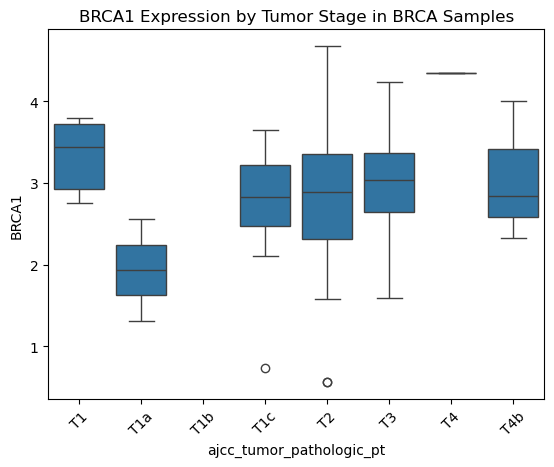

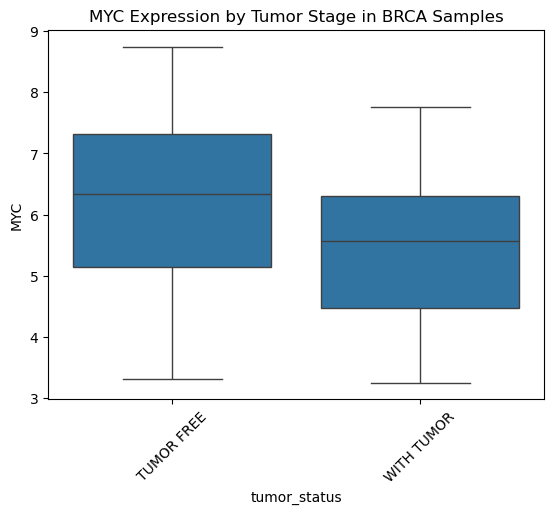

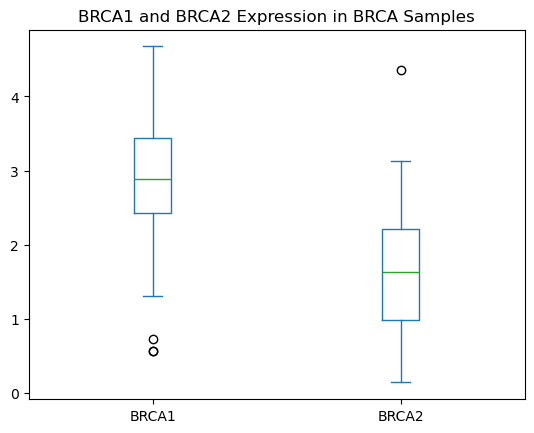

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
data = pd.read_csv(
    r"C:\Users\isabe\Downloads\TRAINING_SET_GSE62944_subsample_log2TPM.csv", index_col=0, header=0)  
metadata_df = pd.read_csv(
    r'C:\Users\isabe\OneDrive\Documents\BME2315\Grosso-Orlando-Module-4-Cancer\data\TRAINING_SET_GSE62944_metadata.csv', index_col=0, header=0)

# Subset the data for a specific cancer type
cancer_type = 'BRCA'  # Breast Invasive Carcinoma

# From metadata, get the rows where "cancer_type" is equal to the specified cancer type
cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
#print(cancer_samples)
# Subset the main data to include only these samples
# When you want a subset of columns, you can pass a list of column names to the data frame in []
BRCA_data = data[cancer_samples]

# Subset by index (genes)
desired_gene_list = ['TP53', 'BRCA1', 'BRCA2', 'EGFR', 'MYC']
gene_list = [gene for gene in desired_gene_list if gene in BRCA_data.index]
for gene in desired_gene_list:
    if gene not in gene_list:
        print(f"Warning: {gene} not found in the dataset.")
BRCA_gene_data = BRCA_data.loc[gene_list]

# Merging datasets
# Merge the subsetted expression data with metadata for BRCA samples,
BRCA_metadata = metadata_df.loc[cancer_samples]
BRCA_merged = BRCA_gene_data.T.merge(
    BRCA_metadata, left_index=True, right_index=True)

# Plotting
# Boxplot of BRCA1 expression and tumor pt in BRCA samples 
sns.boxplot(
    data=BRCA_merged,
    x="ajcc_tumor_pathologic_pt",
    y='BRCA1',
    order=["T1", "T1a", "T1b", "T1c", "T2", "T3", "T4", "T4b"]
)
plt.title("BRCA1 Expression by Tumor Stage in BRCA Samples")
plt.xticks(rotation=45)
plt.show()

#Boxplot of MYC expression and active tumor status in BRCA samples
clean = BRCA_merged[BRCA_merged['tumor_status'].isin(['TUMOR FREE', 'WITH TUMOR'])]
sns.boxplot(
    data = clean,
    x="tumor_status",
    y='MYC',
)
plt.title("MYC Expression by Tumor Stage in BRCA Samples")
plt.xticks(rotation=45)
plt.show()
#%%
# Boxplot of BRCA1 and BRCA2 expression in BRCA samples using PANDAS directly
BRCA_merged[['BRCA1', 'BRCA2']].plot.box()
plt.title("BRCA1 and BRCA2 Expression in BRCA Samples")
plt.show()

## Data Analysis: 

### Methods
The machine learning technique I am using is: *fill in and describe*

*What is this method optimizing? How does the model decide it is "good enough"?*

**

### Analysis
*(Describe how you analyzed the data. This is where you should intersperse your Python code so that anyone reading this can run your code to perform the analysis that you did, generate your figures, etc.)*

## Verify and validate your analysis: 
*Pick a SPECIFIC metric to determine how well your model is performing and describe how it works here.*

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*